In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import os

# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("../CNS Dataset/Raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Remove unwanted spaces in column names
df.columns = df.columns.str.strip()

print("Original dataset shape:", df.shape)

Original dataset shape: (225745, 79)


In [2]:
# -----------------------------
# 2. Data Cleaning
# -----------------------------

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (223082, 79)


In [3]:
# -----------------------------
# 3. Separate Features & Label
# -----------------------------
X = df.drop('Label', axis=1)
y = df['Label']


# -----------------------------
# 4. Encode Labels
# -----------------------------
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [4]:
# -----------------------------
# 5. Train Random Forest Model
# -----------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)


# -----------------------------
# 6. Feature Importance
# -----------------------------
importance = pd.Series(model.feature_importances_, index=X.columns)

# Sort features
top_features = importance.sort_values(ascending=False)

print("\nTop 20 Important Features:\n")
print(top_features.head(20))


# Save top features list
top_features.head(20).to_csv("../CNS Dataset/top_20_features.csv", header=True)
print("\nTop 20 features saved to top_20_features.csv")


Top 20 Important Features:

Fwd Packet Length Max          0.092182
Init_Win_bytes_forward         0.073521
Subflow Fwd Bytes              0.068612
Bwd Packet Length Min          0.067865
Avg Fwd Segment Size           0.066710
Fwd Packet Length Mean         0.062548
Total Length of Fwd Packets    0.054405
Subflow Fwd Packets            0.046416
Destination Port               0.046161
act_data_pkt_fwd               0.042183
Fwd IAT Std                    0.032347
Fwd IAT Total                  0.028455
Fwd Header Length.1            0.024000
Fwd IAT Max                    0.021777
Fwd Header Length              0.021378
Fwd IAT Mean                   0.020197
Bwd Packet Length Max          0.018519
Fwd Packet Length Std          0.014811
Average Packet Size            0.013109
Subflow Bwd Packets            0.011812
dtype: float64

Top 20 features saved to top_20_features.csv


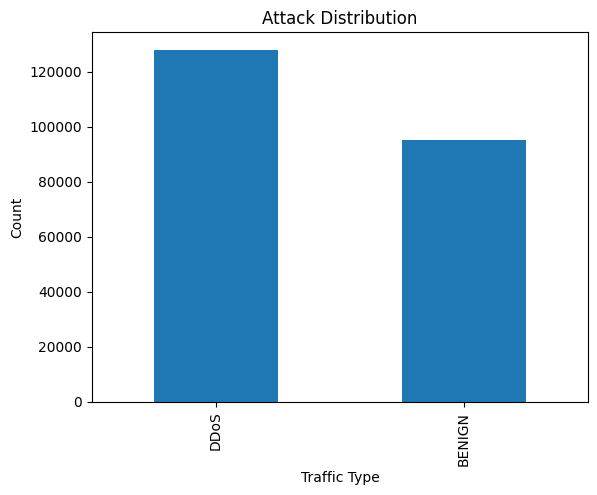

In [5]:
# -----------------------------
# 7. Visualization
# -----------------------------
plt.figure()

df['Label'].value_counts().plot(kind='bar')

plt.title("Attack Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

plt.show()

In [6]:
# -----------------------------
# 8. Create Final Dataset with Top Features
# -----------------------------
top20 = top_features.head(20).index

# Select only important features
X_top = X[top20]

# Add label column
final_df = X_top.copy()
final_df['Label'] = df['Label']

print("\nFinal dataset shape:", final_df.shape)


# -----------------------------
# 9. Save Processed Dataset
# -----------------------------\
os.makedirs("../CNS Dataset/Processed", exist_ok=True)
final_df.to_csv("../CNS Dataset/Processed/processed_network_dataset.csv", index=False)

print("Processed dataset saved as processed_network_dataset.csv")


Final dataset shape: (223082, 21)
Processed dataset saved as processed_network_dataset.csv
